<h1 style = "color : #0EE071; text-align : center;"><em>Nata Project</em> - Feature Management Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook has the funcion of preparing the features for the learning model.</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Machine Learning I</p>
<p style = "font-size : 10px; text-align: center;">Diogo Gonçalves, João Marques, Juan Mendes, Gustavo Franco & Lucas Casimiro</p>
<br>


## <a class="anchor" id="0th-bullet">Table of Contents</a>


* [<b>1. Preparation</b>](#1st-bullet)<br>
    * [1.1 Import the needed libraries and datasets](#2nd-bullet)<br>
    * [1.2 Scaling](#4.5th-bullet)<br>
    
    
* [<b>2. Feature Selection</b>](#5th-bullet)<br>
    * [2.1 Handling Multicolinearity](#6th-bullet)<br>
    * [2.2 Filter methods](#6th-bullet)<br>
        * 2.2.1 Constant features<br>
        * 2.2.2 Spearman Correlation<br>
        * 2.2.3 Chi-Square Test<br>
    * [2.3 Wrapper Methods](#10th-bullet)<br>
        * 2.2.1 RFE<br>
    * [2.4 Embedded Methods](#12th-bullet)<br>
        * 2.3.1 Lasso Regression<br>
        * 2.3.2 Decision Tree<br>
    * [2.5 Final Insights](#15th-bullet)<br>


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 1. Preparation</h2>
<h3 style="color: #0EE071;">1.1 Import the needed libraries and datasets</h3>


In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

import scipy.stats as stats
from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

In [170]:
X_train = pd.read_pickle('Nata_files/data_clean/X_train_clean.pkl')
X_val = pd.read_pickle('Nata_files/data_clean/X_val_clean.pkl')
y_train = pd.read_pickle('Nata_files/data_clean/y_train_clean.pkl')
y_val = pd.read_pickle('Nata_files/data_clean/y_val_clean.pkl')
X_val

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
2642,64.0,34.0,58.0,98.5,57.862214,9.0,425.0,3.1,410.0,211.0,81.22,23.4,4.2,False
2789,50.0,25.0,55.0,97.9,57.862214,9.0,396.0,2.9,409.0,227.0,54.44,23.4,5.5,False
595,70.0,24.0,37.0,98.7,57.862214,10.0,381.0,3.2,373.0,194.0,48.36,79.0,4.6,False
2010,73.0,22.0,34.0,98.9,96.000000,12.0,221.0,3.4,212.0,185.0,39.92,23.2,4.5,False
3229,47.0,33.0,0.0,98.4,59.000000,11.0,111.0,3.5,116.0,180.0,76.41,19.0,5.4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,43.0,25.0,33.0,99.2,78.000000,10.0,319.0,3.1,312.0,269.0,28.19,23.4,4.5,False
1541,43.0,17.0,29.0,97.9,72.000000,10.0,219.0,3.4,233.0,210.0,51.15,55.9,3.7,False
883,49.0,26.0,44.0,95.4,57.862214,11.0,310.0,3.1,316.0,229.0,26.76,72.8,3.2,False
2731,68.0,23.0,38.0,99.0,32.000000,13.0,120.0,3.5,111.0,212.0,66.04,25.0,8.2,True


<h3 style="color: #0EE071;">1.2 Feature Scaling</h3>
<p style = "font-size : 15px;">To optimize our model, we must address the different scales and distributions of our data. In this section, we'll apply Standard Scaling to center all numerical variables at a mean of 0 and variance of 1. This prevents features with larger magnitudes from dominating the model's learning process.</p>

Note: the dataset has only 1 categorical variable, so we didn't create datasets for a singular column.

In [171]:
# Selecting only numerical columns for scaling
X_train_n = X_train.select_dtypes(include=['int64','float64'])
X_val_n = X_val.select_dtypes(include=['int64','float64'])

# Defining the scaler
scaler = RobustScaler()

# Fitting only the training data and transforming both 
X_train_n_scl = scaler.fit_transform(X_train_n)
X_train_n_scl = pd.DataFrame(X_train_n_scl, columns=X_train_n.columns)

X_val_n_scl = scaler.transform(X_val_n)
X_val_n_scl = pd.DataFrame(X_val_n_scl, columns=X_val_n.columns)

X_train

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
893,69.0,38.0,31.0,97.9,61.000000,10.0,151.0,3.2,146.0,312.0,86.75,21.9,6.4,True
1033,75.0,21.0,27.0,97.4,57.862214,10.0,280.0,3.1,267.0,225.0,55.63,87.6,3.2,False
4706,47.0,29.0,29.0,98.9,89.000000,14.0,197.0,3.2,210.0,201.0,34.26,22.0,5.6,False
3072,61.0,29.0,37.0,98.2,36.000000,12.0,161.0,3.3,171.0,153.0,28.66,12.1,3.9,False
4016,76.0,40.0,16.0,97.9,32.000000,9.0,161.0,3.2,159.0,242.0,73.25,22.6,4.6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,62.0,31.0,0.0,97.4,80.000000,11.0,179.0,3.2,180.0,185.0,63.92,15.4,6.8,False
659,78.0,17.0,32.0,97.3,57.862214,9.0,274.0,3.3,278.0,220.0,53.67,13.0,7.8,False
2548,67.0,36.0,24.0,96.6,36.000000,10.0,267.0,3.0,273.0,233.0,26.94,19.3,3.4,False
647,76.0,32.0,40.0,98.8,72.000000,9.0,330.0,3.1,326.0,201.0,61.57,72.2,4.5,False


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 2. Feature Selection</h2>

<h3 style="color: #0EE071;">2.1 Handling Multicolinearity</h3>


As seen in the correlation heatmap in NB1, we see 'oven_temperature' and 'final_temperature' have an extremely high correlation, which means having both is redundant, so we will check for their correlation with the target variable and make a decision to drop the one with the lowest value before getting into the filter methods.

In [172]:
# Correlation analysis before dropping features
analysis_corr = pd.DataFrame(X_train_n_scl, columns=X_train_n.columns)[['oven_temperature', 'final_temperature']].copy()
analysis_corr['quality_class'] = y_train.values

corr_oven = analysis_corr['oven_temperature'].corr(analysis_corr['quality_class'])
corr_final = analysis_corr['final_temperature'].corr(analysis_corr['quality_class'])

print(f"Correlation (Oven Temp vs Target): {corr_oven}")
print(f"Correlation (Final Temp vs Target): {corr_final}")


Correlation (Oven Temp vs Target): -0.050310171852213106
Correlation (Final Temp vs Target): -0.05466262669201594


We conclude that the 'final_temperature' column has a higher absolute correlation, which means it has a better chance of helping to predict the target variable. So, we will drop 'oven_temperature'.

In [173]:
X_train.drop('oven_temperature', axis=1, inplace=True)
X_val.drop('oven_temperature', axis=1, inplace=True)

X_train_n_scl.drop('oven_temperature', axis=1, inplace=True)
X_val_n_scl.drop('oven_temperature', axis=1, inplace=True)

<h3 style="color: #0EE071;">2.2 Filter methods</h3>

### 2.2.1 Constant Features

In [174]:
X_train_n_scl.var().sort_values()

ambient_humidity     0.334618
final_temperature    0.509818
egg_temperature      0.532205
lemon_zest_ph        0.678311
vanilla_extract      0.750809
salt_ratio           0.752906
cream_fat_content    0.795610
baking_duration      0.836084
sugar_content        0.840095
preheating_time      0.961628
cooling_period       1.053738
egg_yolk_count       1.584989
dtype: float64

We conclude that all variables in the dataset exhibit non-zero variance, indicating diversity and variability in their values, so no measures need to be taken.

### 2.1.2. Spearman Correlation

We will now examine the Spearman correlation between variables.  To facilitate this analysis, a new dataframe has been created using all the training data, including the dependent variable. This inclusion allows us to investigate whether any of the independent variables exhibit correlations with the target variable. 



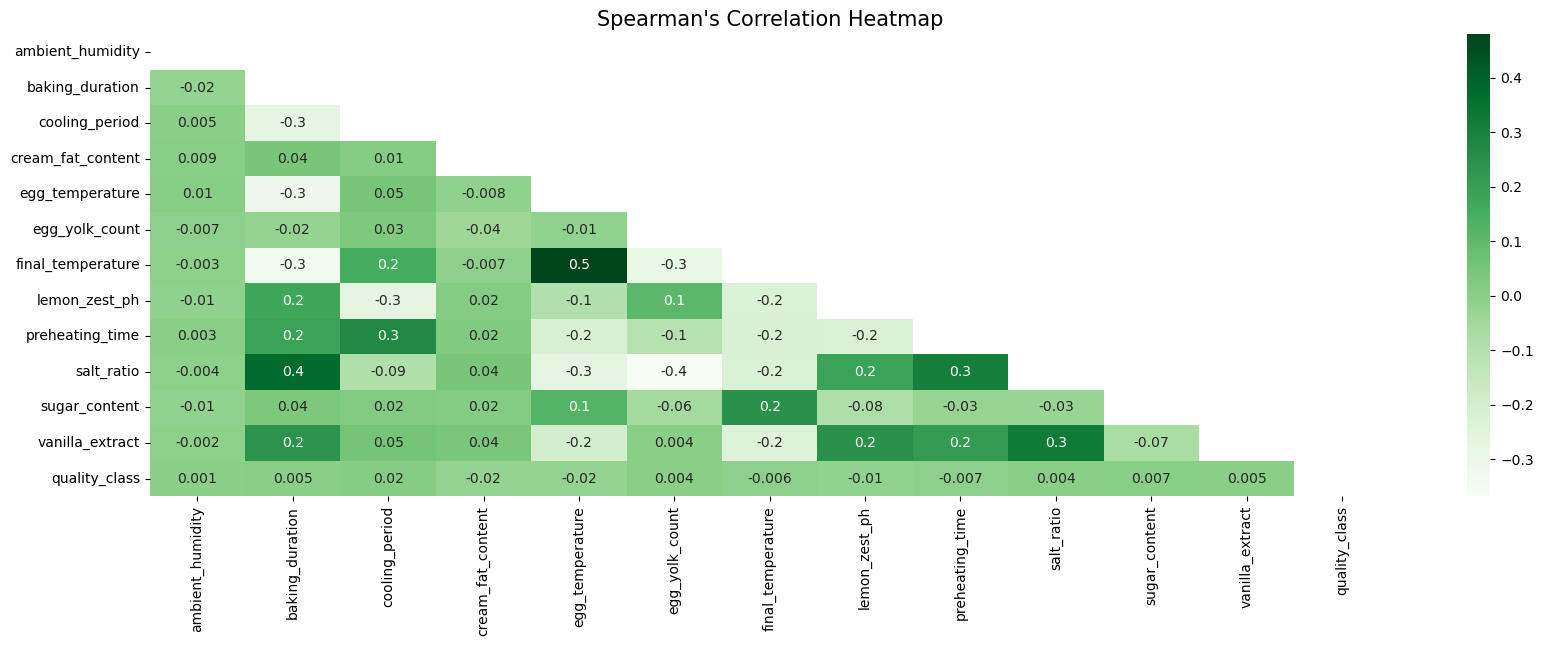

In [175]:
# Joining numerical features and target for correlation analysis
all_train_numerical = X_train_n_scl.join(y_train)

# Computing Spearman's Correlation
correlation = all_train_numerical.corr(method = 'spearman')

# Plotting the lower triangle of the correlation map
def corr_heatmap(correlation):
    plt.figure(figsize=(20, 6))
    ax = sns.heatmap(data = correlation, annot = True, mask = np.triu(np.ones_like(correlation)), cmap = 'Greens', fmt = '.1')
    ax.set_title("Spearman's Correlation Heatmap", fontdict = {'fontsize': 15})
    plt.show()

corr_heatmap(correlation)

We conclude that there are no indendent variables highly correlated with the target variable. However, there is a significant and subtle correlation between 'final_temperature' and 'egg_temperature', which makes logical sense.

Given the absence of strong correlations, it's essential to apply other feature selection methods to gain deeper insights from the dataset.

### 2.1.3. Chi-Square Test

Now, we shift our focus to check for independence on the categorical features with the Chi-Square Test, with a 5% significance level. 

In [176]:
def TestIndependence(X, y,var, alpha=0.05):
    dfObserved = pd.crosstab(y,X) 
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p < alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

For this method, as we only have 1 categorical feature ('origin_porto', which is binarily encoded), we will use a list with this specific case.

In [177]:
cat_variable = ['origin_porto']
for variable in cat_variable:
    TestIndependence(cat_variable, y_train, variable)

origin_porto is NOT an important predictor. (Discard origin_porto from model)


Based on the Chi-Square result, it is recommended to exclude the 'origin_porto' feature.

<h3 style="color: #0EE071;">2.3 Wrapper methods</h3>

In this section we will apply a wrapper method for feature selection. These aim to identify the most impactful subset of features by training different predictive models with varying feature combinations and comparing their performances. We will start by initializing our model.



In [178]:
model = LogisticRegression()

### 2.3.1 RFE

Recursive Feature Elimination will help selecting the most important features to keep.

In [179]:
# Number of features
nof_list = np.arange(1,14)
high_score = 0

# Variable to store the optimum features
nof = 0
score_list = []
for n in range(len(nof_list)):
    rfe = RFE(model,n_features_to_select = nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train_n_scl,y_train)
    X_val_rfe = rfe.transform(X_val_n_scl)
    model.fit(X_train_rfe,y_train)

    score = model.score(X_val_rfe,y_val)
    score_list.append(score)

    if(score > high_score):
        high_score = score
        nof = nof_list[n]

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 12
Score with 12 features: 0.740385


The optimum number of features for this method is 5. So, 5 features will be selected by the RFE model.

In [180]:
rfe = RFE(estimator = model, n_features_to_select = nof)
rfe.fit_transform(X_train_n_scl, y_train)
selected_features = pd.Series(rfe.support_, index = X_train_n_scl.columns)
print(f"Features to keep:\n{selected_features}")

Features to keep:
ambient_humidity     True
baking_duration      True
cooling_period       True
cream_fat_content    True
egg_temperature      True
egg_yolk_count       True
final_temperature    True
lemon_zest_ph        True
preheating_time      True
salt_ratio           True
sugar_content        True
vanilla_extract      True
dtype: bool


<h3 style="color: #0EE071;">2.4 Embedded methods</h3>

We also used Embedded Methods. This technique involves selecting features during the training of predictive models, taking into account their importance.

### 2.4.1 Lasso Regression

The following function was taken from the Machine Learning classes and serves the purpose of constructing a visualization for the feature importance.

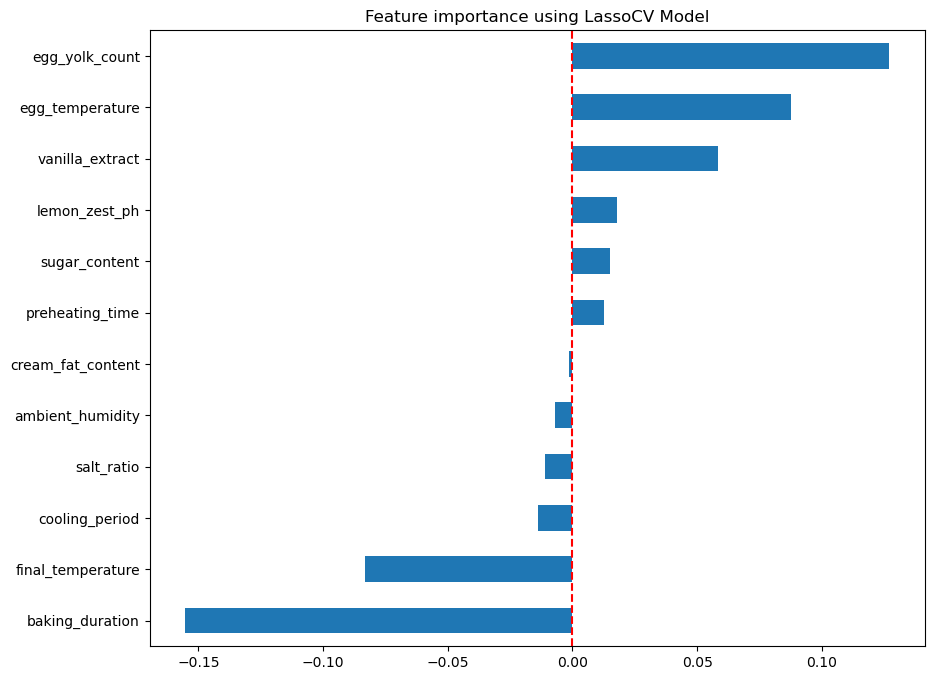

In [181]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(10,8))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

reg = LassoCV()
reg.fit(X_train_n_scl, y_train)
coef = pd.Series(reg.coef_, index = X_train_n_scl.columns)
plot_importance(coef, 'LassoCV')

According to the Lasso Regression, we should discard the 'cream_fat_content' and 'ambient_humidity' columns, as they seem insignificant for the definition of the target when compared to the other variables.

### 2.4.2 Decision tree

While Lasso Regression is great for eliminating features with no linear correlation with the target, it may incorrectly discard features that are useful only in non-linear thresholds or specific combinations. 

For this, we will use a Decision Tree, to address potential ties and limit ambiguity.

Text(0.5, 1.0, 'Feature Importance using Decision Tree Classifier')

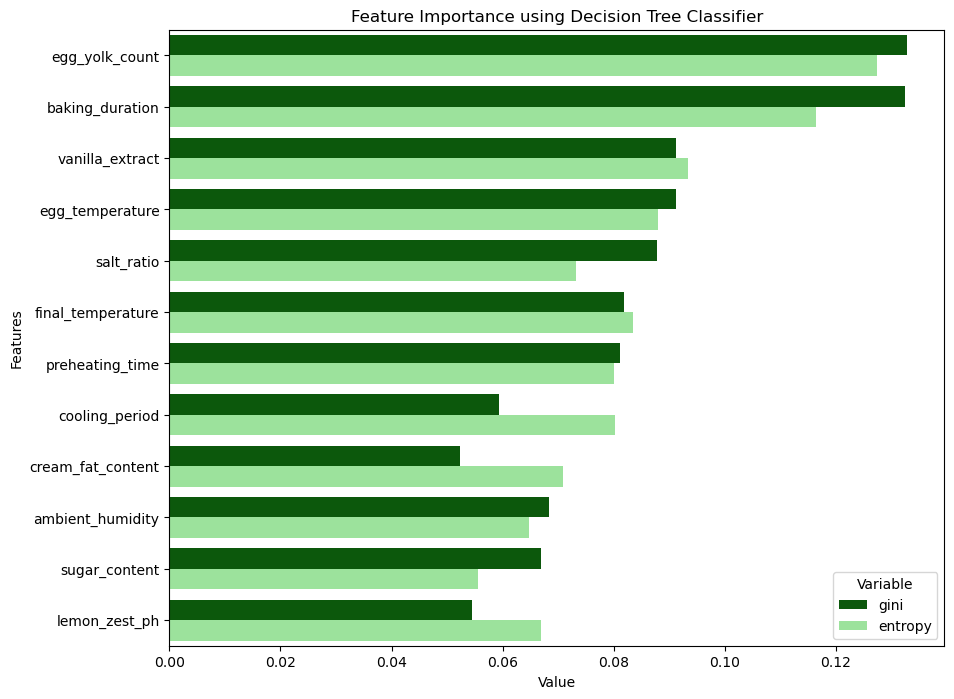

In [182]:
gini_importance = DecisionTreeClassifier(splitter='random', random_state=42).fit(X_train_n_scl, y_train).feature_importances_
entropy_importance = DecisionTreeClassifier(criterion='entropy', splitter='random', random_state=42).fit(X_train_n_scl, y_train).feature_importances_

zippy = pd.DataFrame(zip(gini_importance, entropy_importance), columns=['gini', 'entropy'])
zippy['Features'] = X_train_n_scl.columns
tidy = zippy.melt(id_vars='Features').rename(columns=str.title)
tidy.sort_values(['Value'], ascending=False, inplace=True)

plt.figure(figsize=(10, 8))
sns.barplot(y='Features', x='Value', hue='Variable', data=tidy, palette=['darkgreen', 'lightgreen'])
plt.title("Feature Importance using Decision Tree Classifier")

The columns 'cream_fat_content' and 'ambient_humidity' remain clearly as 2 of the 3 least influential features, joined by 'lemon_zest_ph', which did have a noticeable presence in the LassoCV model, yet is the least valuable from this method.

Also, we have a high disparity between entropy and gini impurity in the 'final_temperature' and 'preheating_time'. Despite both being relevant for the prediction and probably none of them is being removed, we need to understand this difference. 

Entropy's preference for final_temperature indicates that this attribute likely offers substantial "Information Gain" by effectively distinguishing a certain, probably less common, outcome that gini does not emphasize as significantly. 

'preheating_time', on the other hand, appears to function as a strong binary threshold rather than a complex spectrum, as indicated by its higher Gini importance. Gini Impurity favors preheating_time because it is likely to create a OK/KO boundary (e.g., if preheating time is too short, the batch fails).

<h3 style="color: #0EE071;">2.5 Final Insights</h3>

| Numerical Data |  Spearman's Correlation | RFE | Lasso | Decision Tree | Relevance |
| --- | --- | --- | --- | --- | --- 
|  ambient_humidity | Discard |  Keep | Discard | Discard | **Discard** |
|  baking_duration | Discard |  Keep  | Keep | Keep | **Keep** |
|  cooling_period | Discard  |  Keep |  Keep | Keep | **Keep** |
|  cream_fat_content | Discard  |  Discard |  Discard | Discard | **Discard** |
|  egg_temperature  | Discard |  Keep | Keep | Keep | **Keep** |
|  egg_yolk_count  | Discard |  Keep |  Keep | Keep | **Keep** |
|  final_temperature  | Discard |  Keep | Keep | Keep | **Keep** |
|  lemon_zest_ph  | Discard |  Keep | Keep | Discard | **Discard*** |
|  preheating_time  | Discard |  Keep |  Keep | Keep | **Keep** |
|  salt_ratio  | Discard |  Keep |  Keep | Keep | **Keep** |
|  sugar_content  | Discard |  Keep | Keep | Keep | **Keep** |
|  vanilla_extract  | Discard |  Keep | Keep | Keep | **Keep** |

<br>

| Categorical Data | Chi-Square |  Relevance |
| --- | --- | --- |
| origin_porto | Discard |  **Discard**  |

*Given the tie in keeps and discards for this feature, we decided to discard it as our goal is to build a classifier, so the decision tree, which suggested to discard, outweighs the linear methods (RFE and Lasso).

In [183]:
# Join the scaled numerical features with the categorical ones
X_train_join = X_train_n_scl.join(X_train.select_dtypes(include=['bool']))
X_val_join = X_val_n_scl.join(X_val.select_dtypes(include=['bool']))

# Checking the final datasets
display(X_train_join.head())
display(X_val_join.head())

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
0,0.45,1.444444,0.000000,0.000000,0.112064,0.0,-0.635593,0.0,2.575,2.031878,-0.059289,0.764706,False
1,0.75,-0.444444,-0.285714,-0.333333,0.000000,0.0,0.457627,-0.5,0.400,0.469629,2.537549,-1.117647,NaN
2,-0.65,0.444444,-0.142857,0.666667,1.112064,4.0,-0.245763,0.0,-0.200,-0.603163,-0.055336,0.294118,True
3,0.05,0.444444,0.428571,0.200000,-0.780793,2.0,-0.550847,0.5,-1.400,-0.884287,-0.446640,-0.705882,NaN
4,0.80,1.666667,-1.071429,0.000000,-0.923651,-1.0,-0.550847,0.0,0.825,1.354167,-0.031621,-0.294118,False


,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
0,0.20,1.000000,1.928571,0.400000,2.537653e-16,-1.0,1.686441,-0.5,0.050,1.754267,0.000000,-0.529412,NaN
1,-0.50,0.000000,1.714286,0.000000,2.537653e-16,-1.0,1.440678,-1.5,0.450,0.409890,0.000000,0.235294,False
2,0.50,-0.111111,0.428571,0.533333,2.537653e-16,0.0,1.313559,0.0,-0.375,0.104669,2.197628,-0.294118,NaN
3,0.65,-0.333333,0.214286,0.666667,1.362064e+00,2.0,-0.042373,1.0,-0.600,-0.319026,-0.007905,-0.352941,False
4,-0.65,0.888889,-2.214286,0.333333,4.063521e-02,1.0,-0.974576,1.5,-0.725,1.512801,-0.173913,0.176471,NaN


In [184]:
cols_to_drop = ['ambient_humidity', 'cream_fat_content','lemon_zest_ph','origin_porto']

# Dropping less important features on X_train and X_val 
X_train_final = X_train_join.drop(cols_to_drop, axis=1)
X_val_final = X_val_join.drop(cols_to_drop, axis=1)

# Checking the final datasets
display(X_train_final.head())
display(X_val_final.head())

,baking_duration,cooling_period,egg_temperature,egg_yolk_count,final_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
0,1.444444,0.000000,0.112064,0.0,-0.635593,2.575,2.031878,-0.059289,0.764706
1,-0.444444,-0.285714,0.000000,0.0,0.457627,0.400,0.469629,2.537549,-1.117647
2,0.444444,-0.142857,1.112064,4.0,-0.245763,-0.200,-0.603163,-0.055336,0.294118
3,0.444444,0.428571,-0.780793,2.0,-0.550847,-1.400,-0.884287,-0.446640,-0.705882
4,1.666667,-1.071429,-0.923651,-1.0,-0.550847,0.825,1.354167,-0.031621,-0.294118


,baking_duration,cooling_period,egg_temperature,egg_yolk_count,final_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
0,1.000000,1.928571,2.537653e-16,-1.0,1.686441,0.050,1.754267,0.000000,-0.529412
1,0.000000,1.714286,2.537653e-16,-1.0,1.440678,0.450,0.409890,0.000000,0.235294
2,-0.111111,0.428571,2.537653e-16,0.0,1.313559,-0.375,0.104669,2.197628,-0.294118
3,-0.333333,0.214286,1.362064e+00,2.0,-0.042373,-0.600,-0.319026,-0.007905,-0.352941
4,0.888889,-2.214286,4.063521e-02,1.0,-0.974576,-0.725,1.512801,-0.173913,0.176471


Now, our datasets are ready for modeling.

In [ ]:
# Saving the final datasets
# X_train_final.to_pickle('Nata_files/data_clean/X_train_final.pkl')
# X_val_final.to_pickle('Nata_files/data_clean/X_val_final.pkl')  